In [11]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import pygmt
from pygmt_helper import plotting

import nn_gmm as nng

In [2]:
imdb_ffp = Path("/Users/claudy/dev/work/data/nn_gmm/202505_CS200m_imdb.db")

In [33]:
with nng.IMDB(imdb_ffp, readonly=True) as imdb:
    site_0_df = imdb.get_site_df(max_grid_level=0, min_grid_level=0)
    sites = site_0_df.site_id.values.astype(str)
    record_info_df = imdb.get_record_info_df(sites=sites)
    site_event_data = imdb.get_site_event_df(sites=site_0_df.site_id.values.astype(str))
    event_df = imdb.get_event_df()

In [34]:
event_record_info = record_info_df.groupby(["event_int_id", "site_int_id"]).first()

In [37]:
event_record_info

rel_int_id   event_id  site_id           rel_id  \
event_int_id site_int_id                                                    
1            72                    1   AhuririR  0200047   AhuririR_REL01   
             91                    1   AhuririR  020005a   AhuririR_REL01   
             92                    1   AhuririR  020005b   AhuririR_REL01   
             110                   1   AhuririR  020006d   AhuririR_REL01   
             111                   1   AhuririR  020006e   AhuririR_REL01   
...                              ...        ...      ...              ...   
486          3874              16012  Woodville  0200f21  Woodville_REL01   
             3875              16012  Woodville  0200f22  Woodville_REL01   
             3876              16012  Woodville  0200f23  Woodville_REL01   
             3906              16012  Woodville  0200f41  Woodville_REL01   
             3907              16012  Woodville  0200f42  Woodville_REL01   

                               mag  
event_int_id site_int_id            
1            72           6.970411  
             91           6.970411  
             92           6.970411  
             110          6.970411  
             111          6.970411  
...                            ...  
486          3874         6.420448  
             3875         6.420448  
             3876         6.420448  
             3906         6.420448  
             3907         6.420448  

[240293 rows x 5 columns]

In [ ]:
event_record_info["site_int_id"] = event_record_info.index.get_level_values("site_int_id").values
event_record_info["event_int_id"] = event_record_info.index.get_level_values("event_int_id").values
event_record_info.index = nng.utils.get_site_event_int_id(event_record_info["site_int_id"], event_record_info["event_int_id"])


In [45]:
event_record_info["mag"] = event_df.loc[event_record_info.event_int_id.values, "magnitude"].values
event_record_info["rrup"] = site_event_data.loc[event_record_info.index.values, "rrup"].values

In [46]:
event_record_info

,rel_int_id,event_id,site_id,rel_id,mag,site_int_id,event_int_id,rrup
5332269751,1,AhuririR,0200047,AhuririR_REL01,6.970411,72,1,187.069650
6740221328,1,AhuririR,020005a,AhuririR_REL01,6.970411,91,1,176.617175
6808965619,1,AhuririR,020005b,AhuririR_REL01,6.970411,92,1,182.833196
8138768233,1,AhuririR,020006d,AhuririR_REL01,6.970411,110,1,169.273934
8212755660,1,AhuririR,020006e,AhuririR_REL01,6.970411,111,1,172.382138
...,...,...,...,...,...,...,...,...
286114572416,16012,Woodville,0200f21,Woodville_REL01,6.420448,3874,486,74.088110
286191572077,16012,Woodville,0200f22,Woodville_REL01,6.420448,3875,486,71.810459
286269104078,16012,Woodville,0200f23,Woodville_REL01,6.420448,3876,486,70.368580
288482164000,16012,Woodville,0200f41,Woodville_REL01,6.420448,3906,486,81.683868


[Text(0, 4.0, ''),
 Text(0, 4.5, ''),
 Text(0, 5.0, ''),
 Text(0, 5.5, ''),
 Text(0, 6.0, ''),
 Text(0, 6.5, ''),
 Text(0, 7.0, ''),
 Text(0, 7.5, ''),
 Text(0, 8.0, ''),
 Text(0, 8.5, '')]

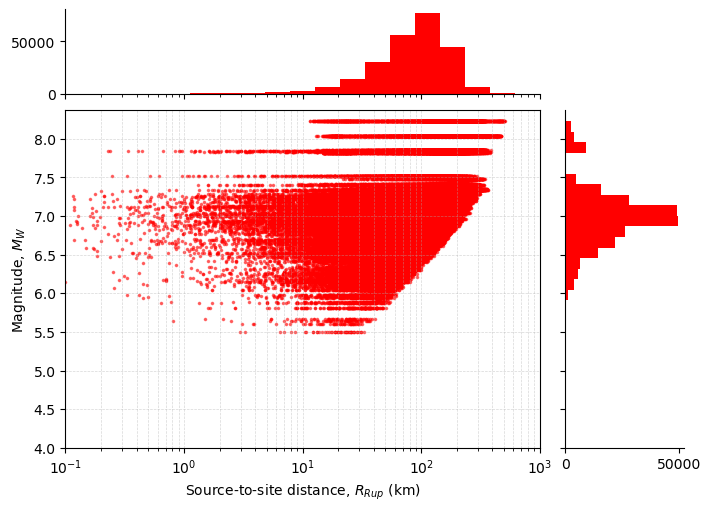

In [ ]:
figsize = (7, 5)
n_rrup_bins = 20
n_mag_bins = 20

fig, axs = plt.subplot_mosaic(
    [["histx", "."], ["scatter", "histy"]],
    width_ratios=(4, 1),
    height_ratios=(1, 4),
    layout="constrained",
    figsize=figsize,
)
ax_scatter = axs["scatter"]
ax_histx = axs["histx"]
ax_histy = axs["histy"]

# Scatter plot
ax_scatter.scatter(
    event_record_info["rrup"],
    event_record_info["mag"],
    s=2.5,
    c="r",
    alpha=0.5,
)

ax_scatter.set_xlabel("Source-to-site distance, $R_{Rup}$ (km)")
ax_scatter.set_ylabel("Magnitude, $M_{W}$")
# ax_scatter.legend()
ax_scatter.set_xscale("log")
ax_scatter.set_xlim(0.1, 1000)
ax_scatter.set_ylim(4.0, None)
ax_scatter.grid(which="both", linewidth=0.5, alpha=0.5, linestyle="--")

ax_histx.hist(
    event_record_info["rrup"],
    bins=np.logspace(np.log10(0.1), np.log10(1000), n_rrup_bins),
    color="red",
)
ax_histx.set_xscale("log")
ax_histx.set_xlim(0.1, 1000)
ax_histx.spines[["top", "right"]].set_visible(False)
ax_histx.set_xticklabels([])

ax_histy.hist(
    event_record_info["mag"],
    bins=n_mag_bins,
    color="red",
    orientation="horizontal",
)
ax_histy.set_ylim(ax_scatter.get_ylim())
ax_histy.spines[["top", "right"]].set_visible(False)
ax_histy.set_yticklabels([])